# Notebook 4 - Ejecucion y Costes

Este notebook implementa el motor operativo del backtest a partir de la seleccion de N3.
Su objetivo es simular ordenes reales, aplicar costes transaccionales y exportar artefactos listos para N5.

## 1) Alcance y reglas operativas del enunciado

Reglas obligatorias aplicadas de forma estricta:
1. Salidas de cartera por rebalance: venta a `OPEN` del dia de rebalanceo.
2. Entradas nuevas por rebalance: compra a `CLOSE` del mismo dia.
3. Comision por orden: `fee = max(abs(notional) * 0.0023, 23)`.
4. Si un activo en cartera sale de mercado o del indice entre rebalanceos: venta forzosa a `CLOSE` del dia del evento y el efectivo queda en liquidez hasta el siguiente rebalanceo.

Flujo temporal explicito:
- `n3_initial_allocation_2014.csv`: cartera inicial de 2014-12-31 para arrancar invertido.
- `n3_selected_assets.csv`: rebalanceos reales desde 2015-01-30.

Politica explicita para seleccionados no ejecutables (`eligible_for_execution=False`):
- **No fill y cash**. No se sustituye por el siguiente rank en ese mismo mes.

Politica explicita de pesos en este N4:
- En cada evento de entrada (initial allocation o rebalance) se intenta objetivo 5% por activo.
- En rebalance mensual se recalibran tambien las posiciones que permanecen en cartera para acercar pesos al 5%.

Regla temporal para eventos forzosos (sin componente ex-post):
- No se usa `max(date)` global por simbolo.
- Se decide dia a dia con informacion observada en `d`.
- Si `in_sp500` pasa de `1` a `0` en `d`: salida exacta a `close(d)`.
- Si no hay cotizacion en `d` para un simbolo en cartera: salida proxy con el ultimo `close` observado (`last_seen_close`), dejando trazabilidad explicita en el log de ordenes.


Comparativa metodologica de politica de pesos (with/without reweight):
- `with_reweight` es la politica base de este N4 por lectura estricta del enunciado:
  repartir capital al 5% en cada activo objetivo de la cartera mensual.
- `without_reweight` se calcula como sensibilidad operativa para cuantificar friccion/coste.
- La comparacion se reporta en la seccion final (equity, fee total, no_fill_cash, turnover)
  para justificar de forma transparente el trade-off entre precision de pesos y coste de ejecucion.


In [1]:
# Librerias permitidas por el enunciado para N4.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Entradas de N1/N2/N3.
N1_RUNTIME_PARAMS_PATH = "data/processed/n1_runtime_params.csv"
N2_EXECUTION_PRICES_PATH = "data/processed/n2_execution_prices.parquet"
N3_SELECTED_PATH = "data/processed/n3_selected_assets.csv"
N3_INITIAL_ALLOCATION_PATH = "data/processed/n3_initial_allocation_2014.csv"
CANONICAL_PATH = "data/processed/sp500_canonical.parquet"

# Salidas de N4 (consumidas por N5).
OUT_N4_ORDERS = "data/processed/n4_orders_log.csv"
OUT_N4_DAILY = "data/processed/n4_portfolio_daily.csv"
OUT_N4_REBALANCE_SUMMARY = "data/processed/n4_rebalance_summary.csv"
OUT_N4_COST_SUMMARY = "data/processed/n4_cost_summary.csv"
OUT_N4_CHECKS = "data/processed/n4_checks.csv"

# Parametros de la estrategia (coherentes con N3 y enunciado).
TOP_N_ASSETS = 20
TARGET_WEIGHT = 0.05


def fail_if(condition: bool, message: str) -> None:
    """Detiene N4 ante un fallo critico de datos o simulacion."""
    if condition:
        raise ValueError(message)


def record_check(
    rows: list,
    check: str,
    passed: bool,
    details: str,
    critical: bool = True,
) -> None:
    """Registra checks de calidad y aplica fail-fast en checks criticos."""
    rows.append(
        {
            "check": check,
            "passed": bool(passed),
            "critical": bool(critical),
            "details": details,
        }
    )
    fail_if(critical and not passed, f"[{check}] {details}")


def load_runtime_params(runtime_path: str) -> dict:
    """Carga parametros de N1 desde CSV key-value."""
    fail_if(
        not pd.io.common.file_exists(runtime_path),
        f"No existe runtime params: {runtime_path}",
    )
    runtime_df = pd.read_csv(runtime_path)
    fail_if(
        not {"parameter", "value"}.issubset(runtime_df.columns),
        "n1_runtime_params.csv no tiene columnas parameter/value.",
    )
    return dict(zip(runtime_df["parameter"], runtime_df["value"]))


def to_float(value: str, default: float) -> float:
    """Convierte string de runtime params a float con fallback."""
    try:
        return float(value)
    except Exception:
        return float(default)


def calc_fee(notional: float, fee_rate: float, fee_min: float) -> float:
    """Calcula comision por orden segun el enunciado."""
    return float(max(abs(notional) * fee_rate, fee_min))


def max_affordable_notional(cash: float, fee_rate: float, fee_min: float) -> float:
    """Maximo notional comprable sin dejar cash negativo, incluyendo comision."""
    if cash <= fee_min:
        return 0.0

    threshold_notional = fee_min / fee_rate
    affordable_with_min_fee = cash - fee_min

    # Tramo con fee minima fija.
    if affordable_with_min_fee <= threshold_notional:
        return max(affordable_with_min_fee, 0.0)

    # Tramo con fee proporcional.
    return cash / (1.0 + fee_rate)


n4_check_rows = []


## 2) Carga de inputs y validaciones de entrada

Se cargan artefactos de N1/N2/N3 y se validan formato, consistencia y cobertura minima.
Si un check critico falla, el notebook se detiene para no contaminar N5.

In [2]:
runtime_params = load_runtime_params(N1_RUNTIME_PARAMS_PATH)

for path in [
    N2_EXECUTION_PRICES_PATH,
    N3_SELECTED_PATH,
    N3_INITIAL_ALLOCATION_PATH,
    CANONICAL_PATH,
]:
    fail_if(not pd.io.common.file_exists(path), f"No existe input requerido: {path}")

initial_capital = to_float(runtime_params.get("initial_capital", "250000"), 250000.0)
fee_rate = to_float(runtime_params.get("transaction_fee_rate", "0.0023"), 0.0023)
fee_min = to_float(runtime_params.get("min_fee_per_order", "23.0"), 23.0)
backtest_start = pd.Timestamp(runtime_params.get("backtest_start", "2015-01-01"))

selected_monthly_df = pd.read_csv(N3_SELECTED_PATH)
initial_allocation_df = pd.read_csv(N3_INITIAL_ALLOCATION_PATH)
execution_df = pd.read_parquet(N2_EXECUTION_PRICES_PATH, engine="pyarrow")
canonical_df = pd.read_parquet(
    CANONICAL_PATH,
    columns=["date", "symbol", "open", "close", "in_sp500"],
    engine="pyarrow",
)

# Tipado robusto para merges y comparaciones temporales.
selected_monthly_df["rebalance_date"] = pd.to_datetime(
    selected_monthly_df["rebalance_date"], errors="coerce"
)
initial_allocation_df["rebalance_date"] = pd.to_datetime(
    initial_allocation_df["rebalance_date"], errors="coerce"
)
execution_df["rebalance_date"] = pd.to_datetime(execution_df["rebalance_date"], errors="coerce")
canonical_df["date"] = pd.to_datetime(canonical_df["date"], errors="coerce")

selected_monthly_df["symbol"] = selected_monthly_df["symbol"].astype("string")
initial_allocation_df["symbol"] = initial_allocation_df["symbol"].astype("string")
execution_df["symbol"] = execution_df["symbol"].astype("string")
canonical_df["symbol"] = canonical_df["symbol"].astype("string")

if "is_initial_allocation" not in selected_monthly_df.columns:
    selected_monthly_df["is_initial_allocation"] = False
if selected_monthly_df["is_initial_allocation"].dtype != bool:
    selected_monthly_df["is_initial_allocation"] = (
        selected_monthly_df["is_initial_allocation"]
        .astype("string")
        .str.lower()
        .map({"true": True, "false": False})
    )
if "is_initial_allocation" not in initial_allocation_df.columns:
    initial_allocation_df["is_initial_allocation"] = True
if initial_allocation_df["is_initial_allocation"].dtype != bool:
    initial_allocation_df["is_initial_allocation"] = (
        initial_allocation_df["is_initial_allocation"]
        .astype("string")
        .str.lower()
        .map({"true": True, "false": False})
    )

monthly_initial_raw_count = int(selected_monthly_df["is_initial_allocation"].sum())
initial_true_raw_count = int(initial_allocation_df["is_initial_allocation"].sum())

# Forzamos el contrato operativo esperado:
# - CSV mensual sin fila inicial.
# - CSV de cartera inicial con flag True.
selected_monthly_df["is_initial_allocation"] = False
initial_allocation_df["is_initial_allocation"] = True

selected_df = pd.concat(
    [initial_allocation_df, selected_monthly_df],
    ignore_index=True,
).sort_values(["rebalance_date", "rank", "symbol"]).reset_index(drop=True)

# 1) Checks de integridad de seleccion N3.
required_selected_cols = [
    "rebalance_date",
    "symbol",
    "rank",
    "target_weight",
    "is_initial_allocation",
]
missing_selected = sorted(set(required_selected_cols) - set(selected_df.columns))
record_check(
    n4_check_rows,
    "n3_selected_required_columns",
    len(missing_selected) == 0,
    f"missing_columns={missing_selected}",
)

record_check(
    n4_check_rows,
    "n3_monthly_csv_excludes_initial_flag",
    monthly_initial_raw_count == 0,
    f"initial_rows_in_monthly_csv={monthly_initial_raw_count}",
)

initial_csv_dates = (
    initial_allocation_df["rebalance_date"].drop_duplicates().sort_values()
)
record_check(
    n4_check_rows,
    "n3_initial_csv_single_date",
    len(initial_csv_dates) == 1,
    (
        f"initial_csv_dates={len(initial_csv_dates)} "
        f"first_initial={initial_csv_dates.min().date() if len(initial_csv_dates) else 'NA'}"
    ),
)
record_check(
    n4_check_rows,
    "n3_initial_csv_has_20_assets",
    len(initial_allocation_df) == TOP_N_ASSETS,
    f"initial_csv_rows={len(initial_allocation_df)}",
)
record_check(
    n4_check_rows,
    "n3_initial_csv_flag_true_rows",
    initial_true_raw_count == len(initial_allocation_df),
    (
        f"initial_true_rows={initial_true_raw_count} "
        f"initial_csv_rows={len(initial_allocation_df)}"
    ),
)

selected_dupes = int(selected_df.duplicated(["rebalance_date", "symbol"]).sum())
record_check(
    n4_check_rows,
    "n3_selected_unique_key",
    selected_dupes == 0,
    f"duplicate_rows={selected_dupes}",
)

selected_counts = selected_df.groupby("rebalance_date", observed=True)["symbol"].size()
bad_count_dates = int((selected_counts != TOP_N_ASSETS).sum())
record_check(
    n4_check_rows,
    "n3_exactly_20_per_rebalance",
    bad_count_dates == 0,
    f"failing_dates={bad_count_dates}",
)

selected_weight_sum = selected_df.groupby("rebalance_date", observed=True)["target_weight"].sum()
bad_weight_dates = int((~np.isclose(selected_weight_sum, 1.0)).sum())
record_check(
    n4_check_rows,
    "n3_weights_sum_to_one",
    bad_weight_dates == 0,
    f"failing_dates={bad_weight_dates}",
)

initial_dates = selected_df.loc[
    selected_df["is_initial_allocation"],
    "rebalance_date",
].drop_duplicates().sort_values()
record_check(
    n4_check_rows,
    "n3_single_initial_allocation_date",
    len(initial_dates) == 1,
    (
        f"initial_dates={len(initial_dates)} "
        f"first_initial={initial_dates.min().date() if len(initial_dates) > 0 else 'NA'}"
    ),
)

initial_allocation_date = initial_dates.min()
initial_assets = int(selected_df["is_initial_allocation"].sum())
record_check(
    n4_check_rows,
    "n3_initial_allocation_has_20_assets",
    initial_assets == TOP_N_ASSETS,
    f"initial_assets={initial_assets}",
)

# 2) Checks de precios de ejecucion N2.
required_exec_cols = [
    "rebalance_date",
    "symbol",
    "open_rebalance",
    "close_rebalance",
    "eligible_for_execution",
]
missing_exec = sorted(set(required_exec_cols) - set(execution_df.columns))
record_check(
    n4_check_rows,
    "n2_execution_required_columns",
    len(missing_exec) == 0,
    f"missing_columns={missing_exec}",
)

exec_dupes = int(execution_df.duplicated(["rebalance_date", "symbol"]).sum())
record_check(
    n4_check_rows,
    "n2_execution_unique_key",
    exec_dupes == 0,
    f"duplicate_rows={exec_dupes}",
)

# 3) Checks calendario bursatil en canonical.
weekend_rows = int((canonical_df["date"].dt.dayofweek >= 5).sum())
record_check(
    n4_check_rows,
    "canonical_no_weekend_rows",
    weekend_rows == 0,
    f"weekend_rows={weekend_rows}",
)

record_check(
    n4_check_rows,
    "params_fee_rate",
    np.isclose(fee_rate, 0.0023),
    f"fee_rate={fee_rate}",
)
record_check(
    n4_check_rows,
    "params_fee_min",
    np.isclose(fee_min, 23.0),
    f"fee_min={fee_min}",
)

# Fechas operativas de N4.
selected_df = selected_df.sort_values(["rebalance_date", "rank", "symbol"]).reset_index(drop=True)
all_signal_dates = pd.Index(selected_df["rebalance_date"].drop_duplicates().sort_values())
monthly_rebalance_dates = all_signal_dates[all_signal_dates != initial_allocation_date]

record_check(
    n4_check_rows,
    "n4_signal_dates_not_empty",
    len(all_signal_dates) > 0,
    f"signal_dates={len(all_signal_dates)}",
)

all_trading_dates = pd.Index(canonical_df["date"].drop_duplicates().sort_values())
pre_backtest_trading_dates = all_trading_dates[all_trading_dates < backtest_start]
expected_initial_date = (
    pre_backtest_trading_dates.max() if len(pre_backtest_trading_dates) > 0 else pd.NaT
)

record_check(
    n4_check_rows,
    "initial_allocation_matches_expected_prestart_date",
    pd.notna(expected_initial_date) and (initial_allocation_date == expected_initial_date),
    (
        f"initial_allocation={initial_allocation_date.date()} "
        f"expected_initial={expected_initial_date.date() if pd.notna(expected_initial_date) else 'NA'}"
    ),
)

record_check(
    n4_check_rows,
    "monthly_rebalance_dates_not_empty",
    len(monthly_rebalance_dates) > 0,
    f"monthly_rebalance_dates={len(monthly_rebalance_dates)}",
)

record_check(
    n4_check_rows,
    "first_monthly_rebalance_after_backtest_start",
    monthly_rebalance_dates.min() >= backtest_start,
    (
        f"first_monthly_rebalance={monthly_rebalance_dates.min().date()} "
        f"backtest_start={backtest_start.date()}"
    ),
)

print("N4 inputs cargados correctamente.")
print("Fechas de senal totales (incluye inicial):", len(all_signal_dates))
print("Fechas de rebalanceo mensual (CSV N3 oficial):", selected_monthly_df['rebalance_date'].nunique())
print("Initial allocation date:", initial_allocation_date.date())
print("Monthly rebalances:", len(monthly_rebalance_dates))
print("First monthly rebalance:", monthly_rebalance_dates.min().date())
print("Initial capital:", initial_capital)


N4 inputs cargados correctamente.
Fechas de senal totales (incluye inicial): 134
Fechas de rebalanceo mensual (CSV N3 oficial): 133
Initial allocation date: 2014-12-31
Monthly rebalances: 133
First monthly rebalance: 2015-01-30
Initial capital: 250000.0


## 3) Motor cronologico de ejecucion y costes

El motor recorre fechas bursatiles en orden y aplica:
1. `initial_allocation` (solo una vez): compras iniciales a `OPEN`.
2. Rebalanceo mensual regular: salidas a `OPEN` y entradas nuevas a `CLOSE`.
3. Eventos forzosos diarios con informacion disponible en cada dia:
   - salida exacta a `CLOSE` cuando `in_sp500` cambia de `1` a `0`.
   - salida proxy (`last_seen_close`) cuando el simbolo en cartera deja de tener cotizacion diaria.
4. Comision por orden con regla exacta del enunciado.

Se registran ordenes, estados de cartera diarios y resumen mensual de rebalanceos,
distinguiendo eventos exactos y aproximaciones operativas.


In [3]:
# Motor de simulacion parametrico para comparar politica con/sin reweight.
def run_backtest(
    selected_df: pd.DataFrame,
    execution_df: pd.DataFrame,
    canonical_df: pd.DataFrame,
    initial_capital: float,
    fee_rate: float,
    fee_min: float,
    initial_allocation_date: pd.Timestamp,
    monthly_rebalance_dates: pd.Index,
    enable_reweight: bool,
) -> dict:
    """Ejecuta el backtest con politica configurable de rebalanceo."""
    execution_lookup = execution_df.set_index(["rebalance_date", "symbol"])
    selected_by_date = {
        dt: frame.sort_values("rank").reset_index(drop=True)
        for dt, frame in selected_df.groupby("rebalance_date", observed=True)
    }

    canonical_core = canonical_df.sort_values(["date", "symbol"]).reset_index(drop=True)
    close_lookup = canonical_core.set_index(["date", "symbol"])["close"]
    open_lookup = canonical_core.set_index(["date", "symbol"])["open"]
    in_sp_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500"]
    canonical_core["in_sp500_prev"] = canonical_core.groupby("symbol", observed=True)["in_sp500"].shift(1)
    in_sp_prev_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500_prev"]

    all_trading_dates = pd.Index(canonical_core["date"].drop_duplicates().sort_values())
    trading_dates = all_trading_dates[
        (all_trading_dates >= initial_allocation_date)
        & (all_trading_dates <= monthly_rebalance_dates.max())
    ]

    cash = float(initial_capital)
    positions = {}
    last_close_cache = {}
    last_seen_close = {}
    last_seen_date = {}

    orders_rows = []
    daily_rows = []
    position_snapshot_rows = []
    open_fallback_count = 0
    monthly_rebalance_set = set(monthly_rebalance_dates.tolist())

    def append_order(
        trade_date: pd.Timestamp,
        symbol: str,
        side: str,
        reason: str,
        status: str,
        price_type: str,
        price: float,
        shares: float,
        notional: float,
        fee: float,
        cash_after: float,
        proxy_price_date: pd.Timestamp | None = None,
    ) -> None:
        orders_rows.append(
            {
                "date": trade_date,
                "symbol": symbol,
                "side": side,
                "reason": reason,
                "status": status,
                "price_type": price_type,
                "price": float(price),
                "shares": float(shares),
                "notional": float(notional),
                "fee": float(fee),
                "cash_after": float(cash_after),
                "proxy_price_date": proxy_price_date,
                "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
            }
        )

    for trade_date in trading_dates:
        is_initial_allocation_day = trade_date == initial_allocation_date
        is_monthly_rebalance_day = trade_date in monthly_rebalance_set

        # A) Initial allocation: compras al OPEN.
        if is_initial_allocation_day:
            target_df = selected_by_date[trade_date]
            target_notional_per_entry = TARGET_WEIGHT * cash

            for _, row in target_df.iterrows():
                symbol = row["symbol"]
                exec_key = (trade_date, symbol)

                if exec_key in execution_lookup.index:
                    exec_row = execution_lookup.loc[exec_key]
                    eligible_exec = bool(exec_row["eligible_for_execution"])
                    open_px = float(exec_row["open_rebalance"])
                else:
                    eligible_exec = False
                    open_px = float(open_lookup.get(exec_key, np.nan))
                    open_fallback_count += 1

                if (not eligible_exec) or (not np.isfinite(open_px)) or (open_px <= 0):
                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="buy",
                        reason="initial_allocation",
                        status="no_fill_non_executable",
                        price_type="open_initial",
                        price=open_px if np.isfinite(open_px) else np.nan,
                        shares=0.0,
                        notional=0.0,
                        fee=0.0,
                        cash_after=float(cash),
                    )
                    continue

                affordable_notional = max_affordable_notional(cash, fee_rate, fee_min)
                trade_notional = min(target_notional_per_entry, affordable_notional)

                if trade_notional <= 0:
                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="buy",
                        reason="initial_allocation",
                        status="no_fill_cash",
                        price_type="open_initial",
                        price=open_px,
                        shares=0.0,
                        notional=0.0,
                        fee=0.0,
                        cash_after=float(cash),
                    )
                    continue

                fee = calc_fee(trade_notional, fee_rate, fee_min)
                total_cash_impact = trade_notional + fee
                fail_if(
                    total_cash_impact - cash > 1e-6,
                    f"Initial allocation con cash insuficiente: {trade_date.date()} {symbol}",
                )

                shares = trade_notional / open_px
                cash -= total_cash_impact
                positions[symbol] = positions.get(symbol, 0.0) + shares
                last_close_cache[symbol] = float(open_px)

                append_order(
                    trade_date=trade_date,
                    symbol=symbol,
                    side="buy",
                    reason="initial_allocation",
                    status="filled",
                    price_type="open_initial",
                    price=open_px,
                    shares=float(shares),
                    notional=float(trade_notional),
                    fee=float(fee),
                    cash_after=float(cash),
                )

        # B) Rebalance mensual: salidas a OPEN y entradas/ajustes a CLOSE.
        if is_monthly_rebalance_day:
            target_df = selected_by_date[trade_date]
            target_symbols = set(target_df["symbol"])
            held_symbols = set(positions.keys())

            exit_symbols = sorted(held_symbols - target_symbols)
            for symbol in exit_symbols:
                exec_key = (trade_date, symbol)

                if exec_key in execution_lookup.index:
                    open_px = float(execution_lookup.loc[exec_key, "open_rebalance"])
                else:
                    open_px = float(open_lookup.get(exec_key, np.nan))
                    open_fallback_count += 1

                if (not np.isfinite(open_px)) or (open_px <= 0):
                    proxy_px = last_seen_close.get(symbol, np.nan)
                    proxy_date = last_seen_date.get(symbol, pd.NaT)
                    fail_if(
                        pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                        (
                            "Salida rebalance sin OPEN ni proxy last_seen: "
                            f"{trade_date.date()} {symbol} open={open_px}"
                        ),
                    )

                    shares = positions.pop(symbol)
                    notional = shares * float(proxy_px)
                    fee = calc_fee(notional, fee_rate, fee_min)
                    cash += notional - fee

                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="sell",
                        reason="forced_exit_no_quote_proxy",
                        status="filled",
                        price_type="close_proxy_last_seen",
                        price=float(proxy_px),
                        shares=float(shares),
                        notional=float(notional),
                        fee=float(fee),
                        cash_after=float(cash),
                        proxy_price_date=proxy_date,
                    )

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                    continue

                shares = positions.pop(symbol)
                notional = shares * open_px
                fee = calc_fee(notional, fee_rate, fee_min)
                cash += notional - fee

                append_order(
                    trade_date=trade_date,
                    symbol=symbol,
                    side="sell",
                    reason="rebalance_exit",
                    status="filled",
                    price_type="open_rebalance",
                    price=open_px,
                    shares=float(shares),
                    notional=float(notional),
                    fee=float(fee),
                    cash_after=float(cash),
                )

                last_close_cache.pop(symbol, None)
                last_seen_close.pop(symbol, None)
                last_seen_date.pop(symbol, None)

            close_by_symbol = {}
            eligible_exec_by_symbol = {}
            for symbol in sorted(target_symbols):
                exec_key = (trade_date, symbol)
                if exec_key in execution_lookup.index:
                    exec_row = execution_lookup.loc[exec_key]
                    close_px = float(exec_row["close_rebalance"])
                    eligible_exec = bool(exec_row["eligible_for_execution"])
                else:
                    close_px = float(close_lookup.get(exec_key, np.nan))
                    eligible_exec = False

                fail_if(
                    pd.isna(close_px) or (close_px <= 0),
                    f"CLOSE invalido en rebalance para target: {trade_date.date()} {symbol}",
                )
                close_by_symbol[symbol] = float(close_px)
                eligible_exec_by_symbol[symbol] = eligible_exec

            equity_reference = float(cash)
            for symbol, shares in positions.items():
                if symbol in close_by_symbol:
                    px_for_equity = close_by_symbol[symbol]
                else:
                    px_for_equity = close_lookup.get((trade_date, symbol), np.nan)
                    fail_if(
                        pd.isna(px_for_equity) or (float(px_for_equity) <= 0),
                        f"CLOSE invalido en rebalance para posicion viva: {trade_date.date()} {symbol}",
                    )
                    px_for_equity = float(px_for_equity)
                equity_reference += float(shares) * float(px_for_equity)

            target_notional_per_symbol = TARGET_WEIGHT * equity_reference

            if enable_reweight:
                # Rebalance completo: recortes de sobrepeso a CLOSE.
                for symbol in sorted(target_symbols):
                    close_px = close_by_symbol[symbol]
                    current_shares = float(positions.get(symbol, 0.0))
                    current_notional = current_shares * close_px
                    delta_notional = target_notional_per_symbol - current_notional
                    if delta_notional >= -1e-9:
                        continue

                    trim_notional = min(-delta_notional, current_notional)
                    if trim_notional <= 0:
                        continue

                    fee = calc_fee(trim_notional, fee_rate, fee_min)
                    shares_to_sell = trim_notional / close_px
                    remaining_shares = current_shares - shares_to_sell

                    if remaining_shares <= 1e-12:
                        positions.pop(symbol, None)
                    else:
                        positions[symbol] = remaining_shares

                    cash += trim_notional - fee
                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="sell",
                        reason="rebalance_reweight",
                        status="filled",
                        price_type="close_rebalance",
                        price=close_px,
                        shares=float(shares_to_sell),
                        notional=float(trim_notional),
                        fee=float(fee),
                        cash_after=float(cash),
                    )

            # Compras a CLOSE.
            for symbol in sorted(target_symbols):
                close_px = close_by_symbol[symbol]

                if enable_reweight:
                    current_shares = float(positions.get(symbol, 0.0))
                    current_notional = current_shares * close_px
                    delta_notional = target_notional_per_symbol - current_notional
                    if delta_notional <= 1e-9:
                        continue
                else:
                    # Politica baseline: solo nuevas entradas, sin reweight de supervivientes.
                    if symbol in positions:
                        continue
                    delta_notional = target_notional_per_symbol

                if not eligible_exec_by_symbol.get(symbol, False):
                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="buy",
                        reason="rebalance_entry",
                        status="no_fill_non_executable",
                        price_type="close_rebalance",
                        price=close_px,
                        shares=0.0,
                        notional=0.0,
                        fee=0.0,
                        cash_after=float(cash),
                    )
                    continue

                affordable_notional = max_affordable_notional(cash, fee_rate, fee_min)
                trade_notional = min(delta_notional, affordable_notional)

                if trade_notional <= 1e-12:
                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="buy",
                        reason="rebalance_entry",
                        status="no_fill_cash",
                        price_type="close_rebalance",
                        price=close_px,
                        shares=0.0,
                        notional=0.0,
                        fee=0.0,
                        cash_after=float(cash),
                    )
                    continue

                fee = calc_fee(trade_notional, fee_rate, fee_min)
                total_cash_impact = trade_notional + fee
                fail_if(
                    total_cash_impact - cash > 1e-6,
                    f"Intento de compra con cash insuficiente: {trade_date.date()} {symbol}",
                )

                shares = trade_notional / close_px
                cash -= total_cash_impact
                positions[symbol] = positions.get(symbol, 0.0) + shares

                last_close_cache[symbol] = float(close_px)
                last_seen_close[symbol] = float(close_px)
                last_seen_date[symbol] = trade_date

                append_order(
                    trade_date=trade_date,
                    symbol=symbol,
                    side="buy",
                    reason="rebalance_entry",
                    status="filled",
                    price_type="close_rebalance",
                    price=close_px,
                    shares=float(shares),
                    notional=float(trade_notional),
                    fee=float(fee),
                    cash_after=float(cash),
                )

        # C) Eventos forzosos diarios.
        for symbol in list(positions.keys()):
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            has_valid_close = pd.notna(close_px) and (float(close_px) > 0)

            if has_valid_close:
                close_px = float(close_px)
                last_close_cache[symbol] = close_px
                last_seen_close[symbol] = close_px
                last_seen_date[symbol] = trade_date

                prev_in = in_sp_prev_lookup.get((trade_date, symbol), np.nan)
                curr_in = in_sp_lookup.get((trade_date, symbol), np.nan)
                index_exit_event = (prev_in == 1) and (curr_in == 0)

                if index_exit_event:
                    shares = positions.pop(symbol)
                    notional = shares * close_px
                    fee = calc_fee(notional, fee_rate, fee_min)
                    cash += notional - fee

                    append_order(
                        trade_date=trade_date,
                        symbol=symbol,
                        side="sell",
                        reason="forced_exit",
                        status="filled",
                        price_type="close_event",
                        price=close_px,
                        shares=float(shares),
                        notional=float(notional),
                        fee=float(fee),
                        cash_after=float(cash),
                    )

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                continue

            proxy_px = last_seen_close.get(symbol, np.nan)
            proxy_date = last_seen_date.get(symbol, pd.NaT)
            fail_if(
                pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                f"No hay close valido ni proxy last_seen para salida forzosa: {trade_date.date()} {symbol}",
            )

            shares = positions.pop(symbol)
            notional = shares * float(proxy_px)
            fee = calc_fee(notional, fee_rate, fee_min)
            cash += notional - fee

            append_order(
                trade_date=trade_date,
                symbol=symbol,
                side="sell",
                reason="forced_exit_no_quote_proxy",
                status="filled",
                price_type="close_proxy_last_seen",
                price=float(proxy_px),
                shares=float(shares),
                notional=float(notional),
                fee=float(fee),
                cash_after=float(cash),
                proxy_price_date=proxy_date,
            )

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

        # D) Valoracion diaria.
        market_value = 0.0
        missing_prices = []
        valuation_rows = []
        for symbol, shares in positions.items():
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            if pd.notna(close_px) and (close_px > 0):
                last_close_cache[symbol] = float(close_px)
                px_for_valuation = float(close_px)
            else:
                px_for_valuation = last_close_cache.get(symbol, np.nan)

            if pd.isna(px_for_valuation) or (px_for_valuation <= 0):
                missing_prices.append(symbol)
                continue

            notional = float(shares) * float(px_for_valuation)
            market_value += notional
            valuation_rows.append(
                {
                    "date": trade_date,
                    "symbol": symbol,
                    "shares": float(shares),
                    "price_for_valuation": float(px_for_valuation),
                    "position_notional": float(notional),
                    "is_rebalance": bool(is_monthly_rebalance_day),
                    "is_initial_allocation": bool(is_initial_allocation_day),
                }
            )

        fail_if(
            len(missing_prices) > 0,
            f"No hay precio de valoracion para posiciones vivas en {trade_date.date()}: {missing_prices[:10]}",
        )

        equity = cash + market_value
        fail_if(equity < -1e-6, f"Equity negativo detectado en {trade_date.date()}: {equity}")

        daily_rows.append(
            {
                "date": trade_date,
                "is_rebalance": bool(is_monthly_rebalance_day),
                "is_initial_allocation": bool(is_initial_allocation_day),
                "cash": float(cash),
                "market_value": float(market_value),
                "equity": float(equity),
                "n_positions": int(len(positions)),
            }
        )
        position_snapshot_rows.extend(valuation_rows)

    orders_df = pd.DataFrame(orders_rows)
    portfolio_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    position_snapshots_df = pd.DataFrame(position_snapshot_rows)

    portfolio_daily_df["daily_return"] = portfolio_daily_df["equity"].pct_change().fillna(0.0)
    portfolio_daily_df["cum_return"] = (
        (1.0 + portfolio_daily_df["daily_return"]).cumprod() - 1.0
    )

    return {
        "orders_df": orders_df,
        "portfolio_daily_df": portfolio_daily_df,
        "position_snapshots_df": position_snapshots_df,
        "open_fallback_count": int(open_fallback_count),
        "trading_dates_count": int(len(trading_dates)),
        "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
    }


sim_with_reweight = run_backtest(
    selected_df=selected_df,
    execution_df=execution_df,
    canonical_df=canonical_df,
    initial_capital=initial_capital,
    fee_rate=fee_rate,
    fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates,
    enable_reweight=True,
)

sim_without_reweight = run_backtest(
    selected_df=selected_df,
    execution_df=execution_df,
    canonical_df=canonical_df,
    initial_capital=initial_capital,
    fee_rate=fee_rate,
    fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates,
    enable_reweight=False,
)

# La salida principal de N4 queda definida por la politica objetivo (con reweight).
orders_df = sim_with_reweight["orders_df"].copy()
portfolio_daily_df = sim_with_reweight["portfolio_daily_df"].copy()
position_snapshots_df = sim_with_reweight["position_snapshots_df"].copy()
open_fallback_count = int(sim_with_reweight["open_fallback_count"])

record_check(
    n4_check_rows,
    "trading_dates_not_empty",
    sim_with_reweight["trading_dates_count"] > 0,
    f"trading_dates={sim_with_reweight['trading_dates_count']}",
)

print("Simulacion N4 completada (politica principal: with_reweight).")
print("Orders rows:", len(orders_df))
print("Daily rows:", len(portfolio_daily_df))


Simulacion N4 completada (politica principal: with_reweight).
Orders rows: 3692
Daily rows: 2787


## 4) Controles de ejecucion y resumen ejecutivo para N5

Este bloque mantiene toda la auditoria tecnica en `n4_checks.csv`,
pero muestra en pantalla solo resumen narrativo y tablas de lectura ejecutiva:
- Resumen de costes N4.
- Comparacion de politicas.

Asi se preserva rigor tecnico sin saturar la lectura con tablas masivas de checks.


N4 READINESS: PASS. El proyecto puede continuar en Notebook_5.

Resumen narrativo de validacion N4:
- Checks criticos superados: 37/37 (estado global: PASS).
- Se valida ejecucion OPEN/CLOSE, comisiones 0.23% con minimo 23$, identidad contable diaria y eventos forzosos con trazabilidad.
- El motor arranca invertido con `n3_initial_allocation_2014.csv` y usa `n3_selected_assets.csv` solo para rebalanceos mensuales.
- `n4_checks.csv` conserva el detalle tecnico completo para auditoria, aunque aqui se muestra solo resumen ejecutivo.

Resumen costes N4:
 initial_capital  final_equity  total_return     total_fee      buy_fee     sell_fee  forced_exit_fee  forced_exit_proxy_fee  initial_allocation_fee  n_filled_orders  n_no_fill_non_executable  n_no_fill_cash
        250000.0   862541.0196      2.493361 136769.633799 68954.111194 67815.522605       638.289359             638.289359              573.680535             3673                         0              19

Comparacion de politicas:
 

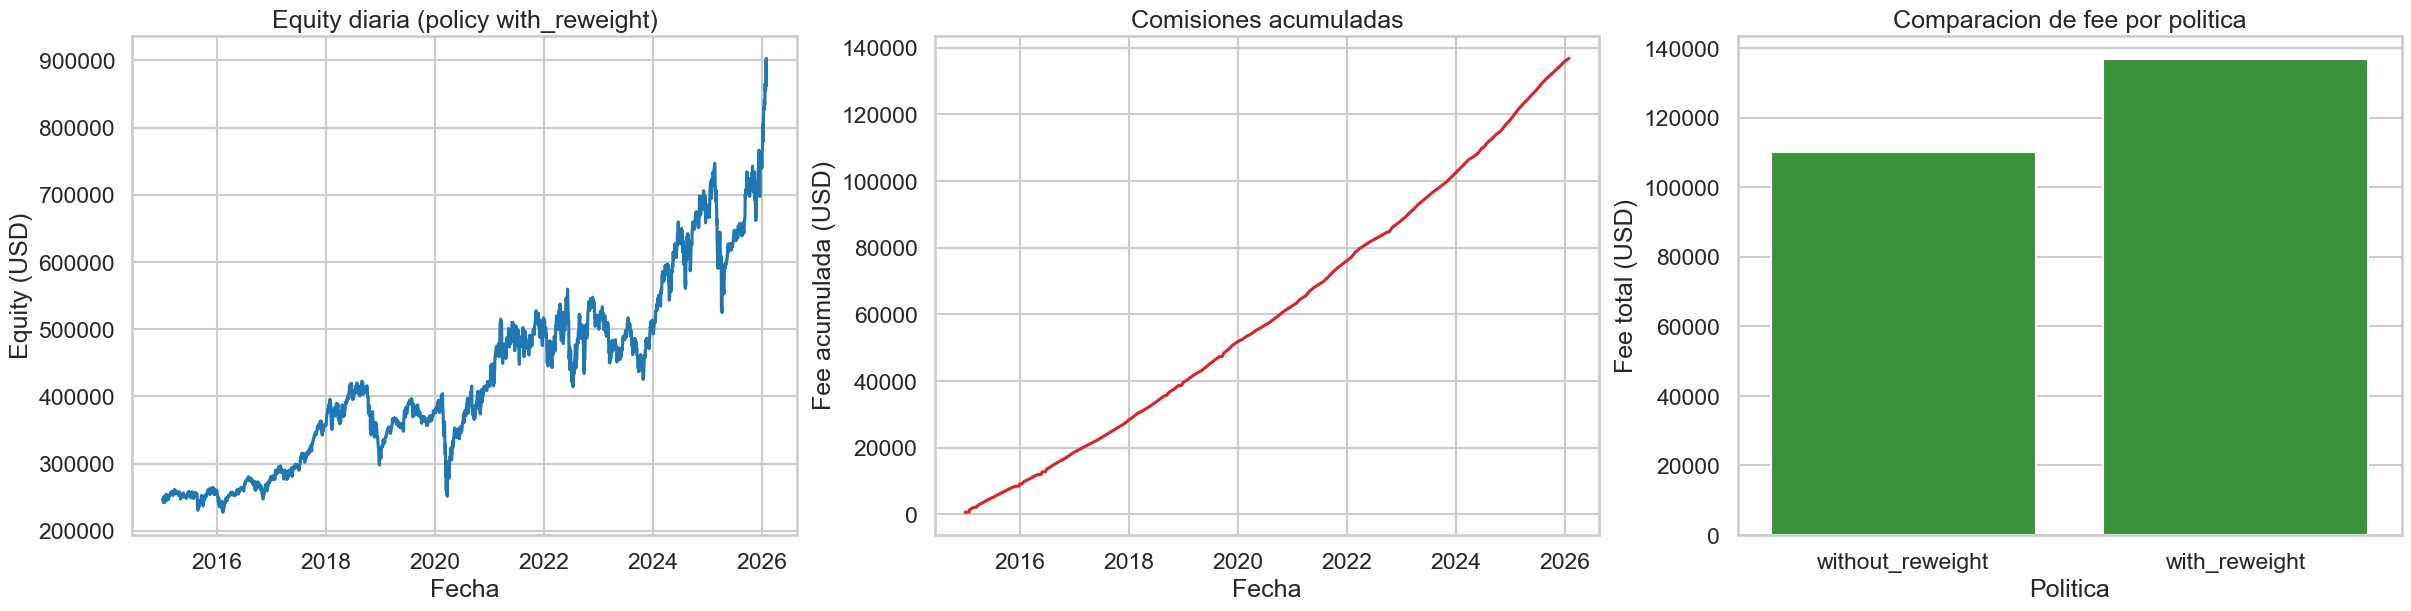

In [4]:
# Resumen por rebalanceo y auditorias complementarias para N5.
if len(orders_df) > 0:
    rebalance_order_stats = (
        orders_df.loc[orders_df["date"].isin(monthly_rebalance_dates)]
        .groupby(["date", "reason", "status"], observed=True)
        .agg(
            n_orders=("symbol", "size"),
            notional=("notional", "sum"),
            fee=("fee", "sum"),
        )
        .reset_index()
    )
else:
    rebalance_order_stats = pd.DataFrame(
        columns=["date", "reason", "status", "n_orders", "notional", "fee"]
    )

rebalance_snapshot = portfolio_daily_df.loc[
    portfolio_daily_df["date"].isin(monthly_rebalance_dates),
    ["date", "cash", "market_value", "equity", "n_positions"],
].copy()

if len(rebalance_order_stats) > 0:
    pvt = rebalance_order_stats.pivot_table(
        index="date",
        columns=["reason", "status"],
        values="n_orders",
        aggfunc="sum",
        fill_value=0,
    )
    pvt.columns = [f"n_{a}_{b}" for a, b in pvt.columns]
    pvt = pvt.reset_index()
else:
    pvt = pd.DataFrame({"date": monthly_rebalance_dates})

rebalance_summary_df = rebalance_snapshot.merge(pvt, on="date", how="left").fillna(0)

filled_orders = orders_df.loc[orders_df.get("status", "") == "filled"].copy()

buy_fee = float(
    filled_orders.loc[filled_orders["side"] == "buy", "fee"].sum()
) if len(filled_orders) else 0.0
sell_fee = float(
    filled_orders.loc[filled_orders["side"] == "sell", "fee"].sum()
) if len(filled_orders) else 0.0
forced_fee = float(
    filled_orders.loc[
        filled_orders["reason"].isin(["forced_exit", "forced_exit_no_quote_proxy"]),
        "fee",
    ].sum()
) if len(filled_orders) else 0.0
forced_proxy_fee = float(
    filled_orders.loc[filled_orders["reason"] == "forced_exit_no_quote_proxy", "fee"].sum()
) if len(filled_orders) else 0.0
initial_fee = float(
    filled_orders.loc[filled_orders["reason"] == "initial_allocation", "fee"].sum()
) if len(filled_orders) else 0.0

cost_summary_df = pd.DataFrame(
    [
        {
            "initial_capital": float(initial_capital),
            "final_equity": float(portfolio_daily_df["equity"].iloc[-1]),
            "total_return": float(portfolio_daily_df["cum_return"].iloc[-1]),
            "total_fee": float(filled_orders["fee"].sum()) if len(filled_orders) else 0.0,
            "buy_fee": buy_fee,
            "sell_fee": sell_fee,
            "forced_exit_fee": forced_fee,
            "forced_exit_proxy_fee": forced_proxy_fee,
            "initial_allocation_fee": initial_fee,
            "n_filled_orders": int(len(filled_orders)),
            "n_no_fill_non_executable": int((orders_df["status"] == "no_fill_non_executable").sum()) if len(orders_df) else 0,
            "n_no_fill_cash": int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0,
        }
    ]
)

# Auditoria identidad contable diaria: equity == cash + market_value.
accounting_identity_df = portfolio_daily_df.copy()
accounting_identity_df["cash_plus_market_value"] = (
    accounting_identity_df["cash"] + accounting_identity_df["market_value"]
)
accounting_identity_df["identity_error"] = (
    accounting_identity_df["equity"] - accounting_identity_df["cash_plus_market_value"]
)
accounting_identity_df["identity_abs_error"] = accounting_identity_df["identity_error"].abs()
accounting_identity_df["identity_ok"] = accounting_identity_df["identity_abs_error"] <= 1e-8

# Auditoria de pesos realizados en fechas de rebalanceo (post-trade a CLOSE).
target_weights_df = selected_df[
    ["rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"]
].copy()

rebalance_positions = (
    position_snapshots_df.loc[position_snapshots_df["date"].isin(all_signal_dates)]
    .groupby(["date", "symbol"], observed=True)
    .agg(realized_notional=("position_notional", "sum"), shares=("shares", "sum"))
    .reset_index()
    .rename(columns={"date": "rebalance_date"})
)

rebalance_equity = (
    portfolio_daily_df.loc[portfolio_daily_df["date"].isin(all_signal_dates), ["date", "equity"]]
    .rename(columns={"date": "rebalance_date", "equity": "rebalance_equity"})
)

weight_realization_df = (
    target_weights_df.merge(
        rebalance_positions,
        on=["rebalance_date", "symbol"],
        how="left",
    )
    .merge(rebalance_equity, on="rebalance_date", how="left")
)
weight_realization_df["realized_notional"] = weight_realization_df["realized_notional"].fillna(0.0)
weight_realization_df["shares"] = weight_realization_df["shares"].fillna(0.0)
weight_realization_df["realized_weight"] = np.where(
    weight_realization_df["rebalance_equity"] > 0,
    weight_realization_df["realized_notional"] / weight_realization_df["rebalance_equity"],
    np.nan,
)
weight_realization_df["weight_deviation"] = (
    weight_realization_df["realized_weight"] - weight_realization_df["target_weight"]
)
weight_realization_df["abs_weight_deviation"] = weight_realization_df["weight_deviation"].abs()
weight_realization_df = weight_realization_df.sort_values(
    ["rebalance_date", "rank", "symbol"]
).reset_index(drop=True)

# Turnover y coste por tipo (reason) + serie temporal diaria.
avg_equity = float(portfolio_daily_df["equity"].mean()) if len(portfolio_daily_df) else np.nan

turnover_by_reason = (
    filled_orders.groupby("reason", observed=True)
    .agg(
        n_orders=("symbol", "size"),
        gross_notional=("notional", lambda s: float(np.abs(s).sum())),
        total_fee=("fee", "sum"),
    )
    .reset_index()
    .rename(columns={"reason": "bucket"})
)
turnover_by_reason["report_type"] = "by_reason"
turnover_by_reason["date"] = pd.NaT
turnover_by_reason["turnover_vs_avg_equity"] = np.where(
    avg_equity > 0,
    turnover_by_reason["gross_notional"] / avg_equity,
    np.nan,
)

turnover_by_date = (
    filled_orders.groupby("date", observed=True)
    .agg(
        n_orders=("symbol", "size"),
        gross_notional=("notional", lambda s: float(np.abs(s).sum())),
        total_fee=("fee", "sum"),
    )
    .reset_index()
)
turnover_by_date = turnover_by_date.merge(
    portfolio_daily_df[["date", "equity"]].rename(columns={"equity": "equity_date"}),
    on="date",
    how="left",
)
turnover_by_date["turnover_vs_avg_equity"] = np.where(
    turnover_by_date["equity_date"] > 0,
    turnover_by_date["gross_notional"] / turnover_by_date["equity_date"],
    np.nan,
)
turnover_by_date["bucket"] = "daily_total"
turnover_by_date["report_type"] = "by_date"

turnover_summary_df = pd.concat(
    [
        turnover_by_reason[
            ["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]
        ],
        turnover_by_date[
            ["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]
        ],
    ],
    ignore_index=True,
)


def build_policy_metrics(sim_result: dict) -> dict:
    """Resume metricas clave para comparar politicas operativas."""
    sim_orders = sim_result["orders_df"].copy()
    sim_daily = sim_result["portfolio_daily_df"].copy()
    sim_filled = sim_orders.loc[sim_orders["status"] == "filled"].copy()

    gross_notional = float(sim_filled["notional"].abs().sum()) if len(sim_filled) else 0.0
    avg_eq = float(sim_daily["equity"].mean()) if len(sim_daily) else np.nan

    return {
        "policy_mode": sim_result["policy_mode"],
        "final_equity": float(sim_daily["equity"].iloc[-1]) if len(sim_daily) else np.nan,
        "total_return": float(sim_daily["cum_return"].iloc[-1]) if len(sim_daily) else np.nan,
        "total_fee": float(sim_filled["fee"].sum()) if len(sim_filled) else 0.0,
        "n_filled_orders": int(len(sim_filled)),
        "n_no_fill_cash": int((sim_orders["status"] == "no_fill_cash").sum()) if len(sim_orders) else 0,
        "gross_notional": gross_notional,
        "turnover_vs_avg_equity": float(gross_notional / avg_eq) if avg_eq and avg_eq > 0 else np.nan,
    }


policy_comparison_df = pd.DataFrame(
    [
        build_policy_metrics(sim_without_reweight),
        build_policy_metrics(sim_with_reweight),
    ]
)

# Checks finales de motor N4.
record_check(
    n4_check_rows,
    "portfolio_daily_not_empty",
    len(portfolio_daily_df) > 0,
    f"rows={len(portfolio_daily_df)}",
)

record_check(
    n4_check_rows,
    "orders_log_generated",
    len(orders_df) > 0,
    f"rows={len(orders_df)}",
)

record_check(
    n4_check_rows,
    "cash_never_negative",
    bool((portfolio_daily_df["cash"] >= -1e-6).all()),
    f"min_cash={float(portfolio_daily_df['cash'].min())}",
)

record_check(
    n4_check_rows,
    "equity_never_negative",
    bool((portfolio_daily_df["equity"] >= -1e-6).all()),
    f"min_equity={float(portfolio_daily_df['equity'].min())}",
)

identity_fail_rows = int((~accounting_identity_df["identity_ok"]).sum())
record_check(
    n4_check_rows,
    "accounting_identity_daily",
    identity_fail_rows == 0,
    f"identity_fail_rows={identity_fail_rows}",
)

if len(filled_orders) > 0:
    expected_fee = np.maximum(
        filled_orders["notional"].abs() * fee_rate,
        fee_min,
    )
    max_fee_error = float((filled_orders["fee"] - expected_fee).abs().max())
else:
    max_fee_error = 0.0

record_check(
    n4_check_rows,
    "fees_follow_rule",
    max_fee_error <= 1e-8,
    f"max_fee_error={max_fee_error}",
)

if len(orders_df) > 0:
    bad_initial_open = int(
        orders_df.loc[
            (orders_df["reason"] == "initial_allocation")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "open_initial")
        ].shape[0]
    )
    bad_exit_open = int(
        orders_df.loc[
            (orders_df["reason"] == "rebalance_exit")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "open_rebalance")
        ].shape[0]
    )
    bad_entry_close = int(
        orders_df.loc[
            (orders_df["reason"] == "rebalance_entry")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "close_rebalance")
        ].shape[0]
    )
    bad_forced_close = int(
        orders_df.loc[
            (orders_df["reason"] == "forced_exit")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "close_event")
        ].shape[0]
    )
    bad_forced_proxy = int(
        orders_df.loc[
            (orders_df["reason"] == "forced_exit_no_quote_proxy")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "close_proxy_last_seen")
        ].shape[0]
    )
    bad_reweight_close = int(
        orders_df.loc[
            (orders_df["reason"] == "rebalance_reweight")
            & (orders_df["status"] == "filled")
            & (orders_df["price_type"] != "close_rebalance")
        ].shape[0]
    )
    missing_proxy_dates = int(
        orders_df.loc[
            (orders_df["reason"] == "forced_exit_no_quote_proxy")
            & (orders_df["status"] == "filled")
            & (orders_df["proxy_price_date"].isna())
        ].shape[0]
    )
    proxy_exit_count = int(
        orders_df.loc[
            (orders_df["reason"] == "forced_exit_no_quote_proxy")
            & (orders_df["status"] == "filled")
        ].shape[0]
    )
else:
    bad_initial_open = 0
    bad_exit_open = 0
    bad_entry_close = 0
    bad_forced_close = 0
    bad_forced_proxy = 0
    bad_reweight_close = 0
    missing_proxy_dates = 0
    proxy_exit_count = 0

record_check(
    n4_check_rows,
    "initial_allocation_entries_at_open",
    bad_initial_open == 0,
    f"bad_rows={bad_initial_open}",
)
record_check(
    n4_check_rows,
    "rebalance_exits_at_open",
    bad_exit_open == 0,
    f"bad_rows={bad_exit_open}",
)
record_check(
    n4_check_rows,
    "rebalance_entries_at_close",
    bad_entry_close == 0,
    f"bad_rows={bad_entry_close}",
)
record_check(
    n4_check_rows,
    "forced_index_exits_at_close",
    bad_forced_close == 0,
    f"bad_rows={bad_forced_close}",
)
record_check(
    n4_check_rows,
    "forced_proxy_exits_use_last_seen_close",
    bad_forced_proxy == 0,
    f"bad_rows={bad_forced_proxy}",
)
record_check(
    n4_check_rows,
    "rebalance_reweight_sells_at_close",
    bad_reweight_close == 0,
    f"bad_rows={bad_reweight_close}",
)
record_check(
    n4_check_rows,
    "forced_proxy_exits_have_proxy_date",
    missing_proxy_dates == 0,
    f"missing_proxy_dates={missing_proxy_dates}",
)
record_check(
    n4_check_rows,
    "forced_proxy_exit_count",
    True,
    f"proxy_exit_count={proxy_exit_count}",
    critical=False,
)

weight_realization_invalid_rows = int(
    (~np.isfinite(weight_realization_df["realized_weight"]).fillna(True)).sum()
)
record_check(
    n4_check_rows,
    "weight_realization_finite",
    weight_realization_invalid_rows == 0,
    f"invalid_rows={weight_realization_invalid_rows}",
)

record_check(
    n4_check_rows,
    "turnover_summary_generated",
    len(turnover_summary_df) > 0,
    f"rows={len(turnover_summary_df)}",
    critical=False,
)

record_check(
    n4_check_rows,
    "policy_comparison_has_two_modes",
    set(policy_comparison_df["policy_mode"]) == {"without_reweight", "with_reweight"},
    f"modes={sorted(policy_comparison_df['policy_mode'].unique())}",
)

with_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "with_reweight"].iloc[0]
without_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "without_reweight"].iloc[0]
record_check(
    n4_check_rows,
    "policy_reweight_tradeoff_documented",
    True,
    (
        f"delta_fee={with_row['total_fee']-without_row['total_fee']:.4f} "
        f"delta_final_equity={with_row['final_equity']-without_row['final_equity']:.4f} "
        f"delta_no_fill_cash={with_row['n_no_fill_cash']-without_row['n_no_fill_cash']}"
    ),
    critical=False,
)

monthly_summary_has_initial = int((rebalance_summary_df["date"] == initial_allocation_date).sum())
record_check(
    n4_check_rows,
    "initial_allocation_excluded_from_monthly_rebalance_summary",
    monthly_summary_has_initial == 0,
    f"initial_rows_in_summary={monthly_summary_has_initial}",
)

record_check(
    n4_check_rows,
    "monthly_rebalance_summary_row_count",
    len(rebalance_summary_df) == len(monthly_rebalance_dates),
    (
        f"summary_rows={len(rebalance_summary_df)} "
        f"monthly_rebalances={len(monthly_rebalance_dates)}"
    ),
)

record_check(
    n4_check_rows,
    "rebalance_exit_open_fallback_count",
    True,
    f"fallback_rows={open_fallback_count}",
    critical=False,
)

# Exportes N4 para N5.
# Nota de trazabilidad:
# Los diagnosticos avanzados (weight_realization, accounting_identity,
# turnover_summary y policy_comparison) se conservan en memoria y se muestran
# en el notebook, pero no se exportan como CSV para mantener un set compacto.
orders_df.to_csv(OUT_N4_ORDERS, index=False)
portfolio_daily_df.to_csv(OUT_N4_DAILY, index=False)
rebalance_summary_df.to_csv(OUT_N4_REBALANCE_SUMMARY, index=False)
cost_summary_df.to_csv(OUT_N4_COST_SUMMARY, index=False)

n4_checks_df = pd.DataFrame(n4_check_rows)
n4_checks_df.to_csv(OUT_N4_CHECKS, index=False)

artifacts_status = {
    "orders_log_csv": pd.io.common.file_exists(OUT_N4_ORDERS),
    "portfolio_daily_csv": pd.io.common.file_exists(OUT_N4_DAILY),
    "rebalance_summary_csv": pd.io.common.file_exists(OUT_N4_REBALANCE_SUMMARY),
    "cost_summary_csv": pd.io.common.file_exists(OUT_N4_COST_SUMMARY),
    "checks_csv": pd.io.common.file_exists(OUT_N4_CHECKS),
}

ready_for_n5 = {
    "all_critical_checks_passed": bool(
        n4_checks_df.loc[n4_checks_df["critical"], "passed"].all()
    ),
    "orders_exported": artifacts_status["orders_log_csv"],
    "portfolio_exported": artifacts_status["portfolio_daily_csv"],
    "summary_exported": artifacts_status["rebalance_summary_csv"],
    "costs_exported": artifacts_status["cost_summary_csv"],
    "checks_exported": artifacts_status["checks_csv"],
}

fail_if(
    not all(ready_for_n5.values()),
    "N4 readiness FAILED: revisar checks y exportes.",
)

# Visuales de control.
fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)

sns.lineplot(data=portfolio_daily_df, x="date", y="equity", ax=axes[0], color="#1f77b4")
axes[0].set_title("Equity diaria (policy with_reweight)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Equity (USD)")

if len(filled_orders) > 0:
    fee_curve = (
        filled_orders.sort_values("date")
        .groupby("date", observed=True)["fee"]
        .sum()
        .cumsum()
        .rename("cum_fee")
        .reset_index()
    )
else:
    fee_curve = pd.DataFrame({"date": portfolio_daily_df["date"], "cum_fee": 0.0})

sns.lineplot(data=fee_curve, x="date", y="cum_fee", ax=axes[1], color="#d62728")
axes[1].set_title("Comisiones acumuladas")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Fee acumulada (USD)")

sns.barplot(data=policy_comparison_df, x="policy_mode", y="total_fee", ax=axes[2], color="#2ca02c")
axes[2].set_title("Comparacion de fee por politica")
axes[2].set_xlabel("Politica")
axes[2].set_ylabel("Fee total (USD)")

print("N4 READINESS: PASS. El proyecto puede continuar en Notebook_5.")
critical_checks = n4_checks_df.loc[n4_checks_df["critical"]]
critical_ok = bool(critical_checks["passed"].all())
critical_passed = int(critical_checks["passed"].sum())
critical_total = int(len(critical_checks))

print("\nResumen narrativo de validacion N4:")
print(
    f"- Checks criticos superados: {critical_passed}/{critical_total} "
    f"(estado global: {'PASS' if critical_ok else 'FAIL'})."
)
print(
    "- Se valida ejecucion OPEN/CLOSE, comisiones 0.23% con minimo 23$, "
    "identidad contable diaria y eventos forzosos con trazabilidad."
)
print(
    "- El motor arranca invertido con `n3_initial_allocation_2014.csv` "
    "y usa `n3_selected_assets.csv` solo para rebalanceos mensuales."
)
print(
    "- `n4_checks.csv` conserva el detalle tecnico completo para auditoria, "
    "aunque aqui se muestra solo resumen ejecutivo."
)

print("\nResumen costes N4:")
print(cost_summary_df.to_string(index=False))

print("\nComparacion de politicas:")
print(policy_comparison_df.to_string(index=False))


# Excepciones operativas clave (evidencia de ejecucion real).
no_fill_cash_df = orders_df.loc[
    orders_df["status"] == "no_fill_cash",
    ["date", "symbol", "side", "reason", "status", "price_type", "price", "cash_after", "policy_mode"],
].copy()
no_fill_cash_df = no_fill_cash_df.sort_values(["date", "symbol"]).reset_index(drop=True)

forced_proxy_df = orders_df.loc[
    (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled"),
    ["date", "symbol", "side", "reason", "price_type", "price", "proxy_price_date", "fee", "policy_mode"],
].copy()
forced_proxy_df = forced_proxy_df.sort_values(["date", "symbol"]).reset_index(drop=True)

no_fill_dates = int(no_fill_cash_df["date"].nunique()) if len(no_fill_cash_df) else 0
forced_proxy_fee_total = float(forced_proxy_df["fee"].sum()) if len(forced_proxy_df) else 0.0
forced_proxy_date_min = (
    pd.Timestamp(forced_proxy_df["date"].min()).date() if len(forced_proxy_df) else "NA"
)
forced_proxy_date_max = (
    pd.Timestamp(forced_proxy_df["date"].max()).date() if len(forced_proxy_df) else "NA"
)

print("\nExcepciones operativas clave (evidencia real de la ejecucion):")
print(
    "- no_fill_cash: "
    f"{len(no_fill_cash_df)} ordenes en {no_fill_dates} fechas; "
    "todas son rebalance_entry por restriccion de caja + comision."
)
print(
    "- Politica aplicada: no se sustituye por rank 21 en el mismo mes; "
    "el capital permanece en liquidez."
)
print(
    "- forced_exit_no_quote_proxy: "
    f"{len(forced_proxy_df)} casos, rango {forced_proxy_date_min} a {forced_proxy_date_max}, "
    f"fee total={forced_proxy_fee_total:.2f}."
)
print(
    "- Convencion operativa: si no hay cotizacion en el dia del evento, "
    "se usa close_proxy_last_seen con proxy_price_date para trazabilidad."
)

print("\nTabla resumen no_fill_cash (primeros 20 casos):")
print(no_fill_cash_df.head(20).to_string(index=False))

print("\nTabla resumen forced_exit_no_quote_proxy (todos los casos):")
print(forced_proxy_df.to_string(index=False))


## Fin Notebook 4

Se han generado los artefactos de ejecucion y costes necesarios para N5,
con arranque invertido trazable (cartera inicial separada) y rebalanceos mensuales auditables.
